# Лабораторная работа №1
## Введение в машинное обучение и подготовка данных

## Импорт необходимых библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## Загрузка и первичный анализ данных. Удаление бесполезных признаков. Разведочный анализ. Средний баланс клиентов по сфере занятости

In [2]:
df = pd.read_csv("bank.csv")

print(f"Размер датасета: {df.shape[0]} клиентов и {df.shape[1]} признаков")
print(df.columns)
df.info()
df = df.drop(["contact", "day", "month"], axis=1)

economic_stats = df.groupby("job")[["balance"]].mean()
print("\nСредний баланс клиентов по сфере работы:\n", economic_stats)

print("\nПервые 3 строки данных")
df.head(3)

Размер датасета: 11162 клиентов и 17 признаков
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  

,age,job,marital,education,default,balance,housing,loan,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,1389,1,-1,0,unknown,yes


## Анализ распределения баланса клиентов


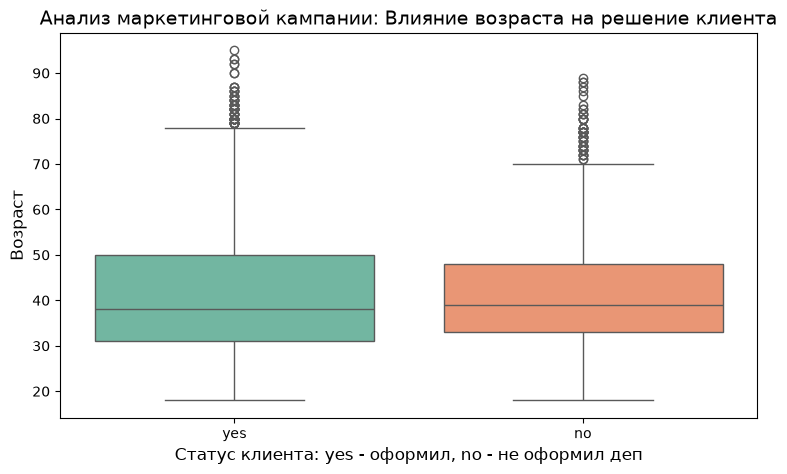

In [3]:
plt.figure(figsize=(9,5))

sns.boxplot(x="deposit", y="age", data=df, palette="Set2", legend=False, hue="deposit")

plt.title("Анализ маркетинговой кампании: Влияние возраста на решение клиента", fontsize=14)
plt.xlabel("Статус клиента: yes - оформил, no - не оформил деп", fontsize=12)
plt.ylabel("Возраст", fontsize=12)
plt.show()

### Аналитический вывод

На графике представлено распределение возраста клиентов в зависимости от решения об открытии срочного депозита. Значения возраста в обеих группах находится в относительно близком диапазоне, но клиенты в возрасте от 30-50 лет чаще открывают срочный депозит.

## Предобработка и преобразование признаков. Разделение признаков и целевой переменной


In [4]:
y = df["deposit"].map({
    "no": 0,
    "yes": 1
})


X = pd.get_dummies(df.drop("deposit", axis=1), columns=["marital", "default", "job", "education", "housing", "loan", "poutcome"], drop_first=True)

print("Данные после обработки категориальных признаков")
X.head(3)

Данные после обработки категориальных признаков


,age,balance,duration,campaign,pdays,previous,marital_married,marital_single,default_yes,job_blue-collar,...,job_unemployed,job_unknown,education_secondary,education_tertiary,education_unknown,housing_yes,loan_yes,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343,1042,1,-1,0,True,False,False,False,...,False,False,True,False,False,True,False,False,False,True
1,56,45,1467,1,-1,0,True,False,False,False,...,False,False,True,False,False,False,False,False,False,True
2,41,1270,1389,1,-1,0,True,False,False,False,...,False,False,True,False,False,True,False,False,False,True


## Разделение данных и масштабирование признаков

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.2, random_state=42, stratify=y 
)

numeric_cols = [
    "age",
    "balance",
    "duration",
    "campaign",
    "pdays",
    "previous"
]
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])
X_train.head(3)

,age,balance,duration,campaign,pdays,previous,marital_married,marital_single,default_yes,job_blue-collar,...,job_unemployed,job_unknown,education_secondary,education_tertiary,education_unknown,housing_yes,loan_yes,poutcome_other,poutcome_success,poutcome_unknown
4850,-1.402801,0.334334,-0.430529,1.771346,-0.497867,-0.371966,False,True,False,False,...,False,False,True,False,False,False,False,False,False,True
7034,1.502968,-0.255210,-0.729113,-0.170522,-0.497867,-0.371966,True,False,True,False,...,False,False,False,True,False,False,True,False,False,True
2185,0.562866,0.892376,-0.463705,-0.170522,-0.497867,-0.371966,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True


## Обучение модели машинного обучения. Оценка качества модели

In [6]:
model = RandomForestClassifier(
    n_estimators=100, random_state = 42, class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred) * 100

print(f"Общая точность модели (Accuracy): {accuracy:.2f}%\n")

Общая точность модели (Accuracy): 80.58%



## Финальный бизнес-вывод

Была построена модель машинного обучения для прогнозирования решения клиента об открытии срочного банковского депозита.Полученная точность модели показывает, какую долю клиентов модель смогла правильно классифицировать. Использование такой модели может помочь банку повысить эффективность маркетинговых кампаний, а на основе прогнозов можно выделять клиентов, которые с большей вероятностью согласятся на открытие депозита. Это позволит более разумно использовать ресурсы банка и повышать эффективность рекламных кампаний.